# Exploration — Coordination & Sémantique

**Responsable** : Malo
**Corpus** : `Dataset/data.xlsx` — 35 396 tweets, 19 mars → 1er mai 2026
**Règle** : tout passe par `load_corpus()`, jamais de lecture directe du fichier Excel.

---
Ce notebook couvre deux des cinq axes d'analyse de la mission (cf. `docs/Datathon_mastere.pdf`) :

- **Coordination** — *est-ce orchestré ?* synchronicité multi-comptes, rafales mono-compte, copier-coller, comptes récents.
- **Sémantique** — *sur quel ton ?* vocabulaire dominant, glissement de vocabulaire, agressivité lexicale, escalade.

Les calculs et les figures viennent des fonctions de `tools/coord_sem.py`, pour rester
cohérent avec le script batch (`python -m tools.coord_sem`). Ce notebook ne fait
qu'appeler ces fonctions et commenter les résultats.

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'figure.figsize':   (12, 4),
    'font.size':        12,
})

from src.tools.corpus_loader import load_corpus
from src.tools.coord_sem import (
    _synchronicity, _rapid_fire, _copy_paste, _recent_accounts,
    _dominant_vocabulary, _vocabulary_shift, _aggressiveness, _escalation,
)

In [5]:
df = load_corpus('../Dataset/data.xlsx')

df = df.drop(["Impressions", "Gender"], axis=1)       # données non exploitables
df = df.drop(["City", "City Code"], axis=1)            # trop de valeurs manquantes
df = df.drop(["Domain", "Language", "Country"], axis=1) # valeur constante dans ce corpus

[load_corpus] 35,396 tweets | 2026-03-19 → 2026-05-01 | RETWEET=30,368 REPLY=3,623 QUOTE=734


## Coordination — est-ce orchestré ?

### 1. Synchronicité — rafales multi-comptes

Une rafale synchrone = beaucoup d'auteurs **différents** postent dans la même fenêtre
de 5 minutes. Le seuil est le 95ᵉ percentile du nombre d'auteurs distincts par fenêtre.

--- Synchronicité (rafales multi-comptes) ---
Fenêtres de 5min : 5609 | seuil p95 = 24 auteurs distincts
312 fenêtres synchrones au-dessus du seuil, ex. top 5 :
Date
2026-03-26 15:05:00    64
2026-03-26 16:55:00    63
2026-03-26 17:15:00    63
2026-03-26 14:50:00    61
2026-03-26 15:20:00    60
Name: X Author ID, dtype: int64
[plot] /home/malo/Documents/PycharmProjects/Datathon/backend/src/outputs/coord_sem/coordination_synchronicite.png


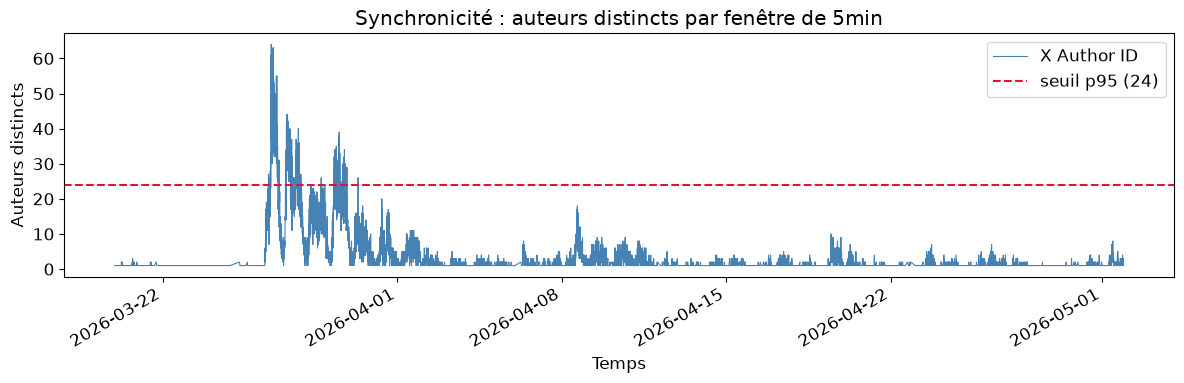

Date
2026-03-26 15:05:00    64
2026-03-26 16:55:00    63
2026-03-26 17:15:00    63
2026-03-26 14:50:00    61
2026-03-26 15:20:00    60
2026-03-26 15:35:00    59
2026-03-26 16:00:00    58
2026-03-26 15:10:00    57
2026-03-26 16:05:00    57
2026-03-26 16:40:00    57
Name: X Author ID, dtype: int64

In [6]:
bursts = _synchronicity(df, plot=True)
bursts.head(10)

### 2. Rapid-fire — rafales mono-compte

Un même compte enchaîne plusieurs posts à moins de 60 secondes d'intervalle —
signature typique d'un compte scripté ou automatisé.

--- Rapid-fire (rafales mono-compte) ---
2437 posts enchaînés en ≤ 60s, par 947 comptes
Top comptes rapid-fire :
X Author ID
1481202746804031494    48
1871917651             38
239096580              38
779831574              33
1325782323753791489    32
767877234              24
2151552378             24
878742191077806080     24
1192767230             23
1736721208597524480    19
dtype: int64
[plot] /home/malo/Documents/PycharmProjects/Datathon/outputs/coord_sem/coordination_rapid_fire.png


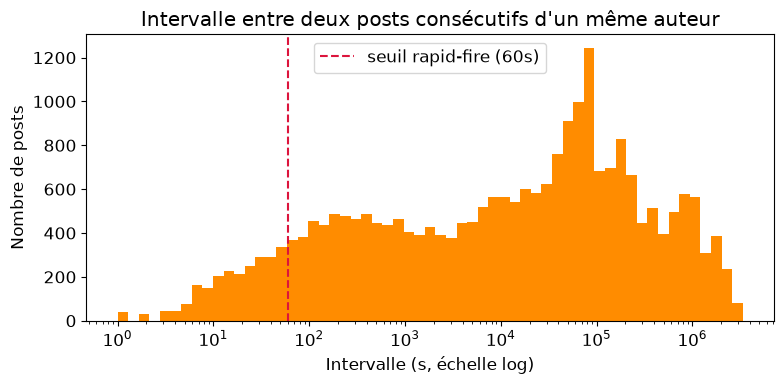

X Author ID
1481202746804031494    48
1871917651             38
239096580              38
779831574              33
1325782323753791489    32
767877234              24
2151552378             24
878742191077806080     24
1192767230             23
1736721208597524480    19
dtype: int64

In [4]:
rapid_fire = _rapid_fire(df, plot=True)
rapid_fire.head(10)

### 3. Copier-coller — messages identiques (hors retweets)

Deux lectures distinctes du même phénomène :
- **inter-comptes** : le même texte posté par ≥ 2 comptes différents → coordination réelle ;
- **intra-compte** : un même compte répète son propre texte → spam scripté.

--- Copier-coller (messages identiques, hors retweets) ---
Inter-comptes : 0 messages identiques diffusés par ≥ 2 comptes différents (0 posts concernés)
Intra-compte : 19 textes répétés ≥ 2 fois par le même compte, par 7 comptes (49 posts concernés)
[plot] /home/malo/Documents/PycharmProjects/Datathon/outputs/coord_sem/coordination_copy_paste.png


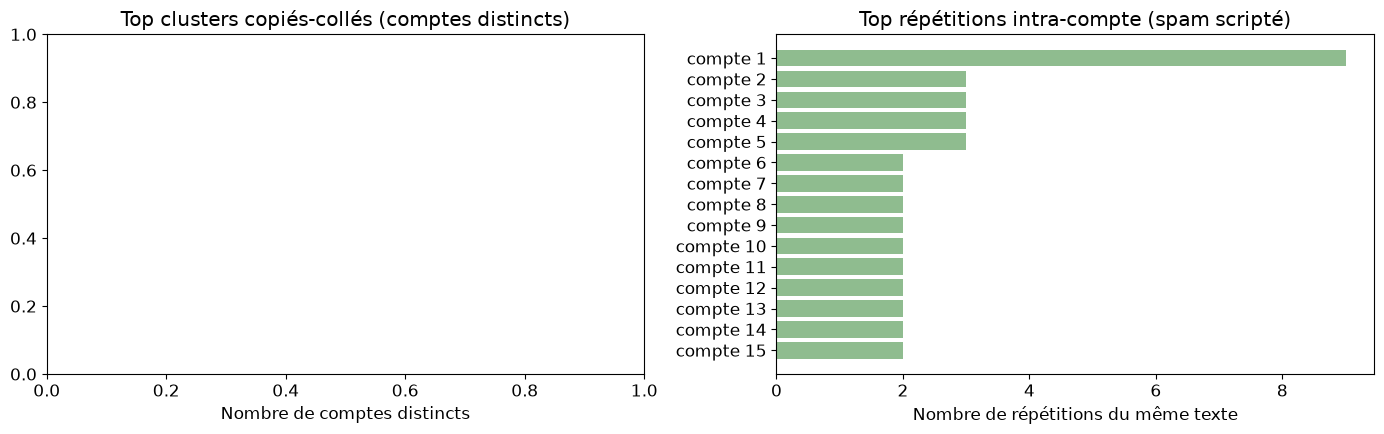

{'cross_account': {'texts': 0, 'posts': np.int64(0)},
 'same_account': {'texts': 19, 'posts': np.int64(49), 'authors': 7}}

In [5]:
copy_paste = _copy_paste(df, plot=True)
copy_paste

### 4. Comptes récents

Pas de date de création de compte dans le corpus : `X Posts` (volume de posts cumulé du
compte) sert de proxy pour repérer les comptes peu actifs/récents.

--- Comptes récents (proxy X Posts) ---
Seuil 'compte récent' de X Posts = 100 posts cumulés
0.5% des tweets du corpus proviennent de comptes sous ce seuil
[plot] /home/malo/Documents/PycharmProjects/Datathon/outputs/coord_sem/coordination_comptes_recents.png


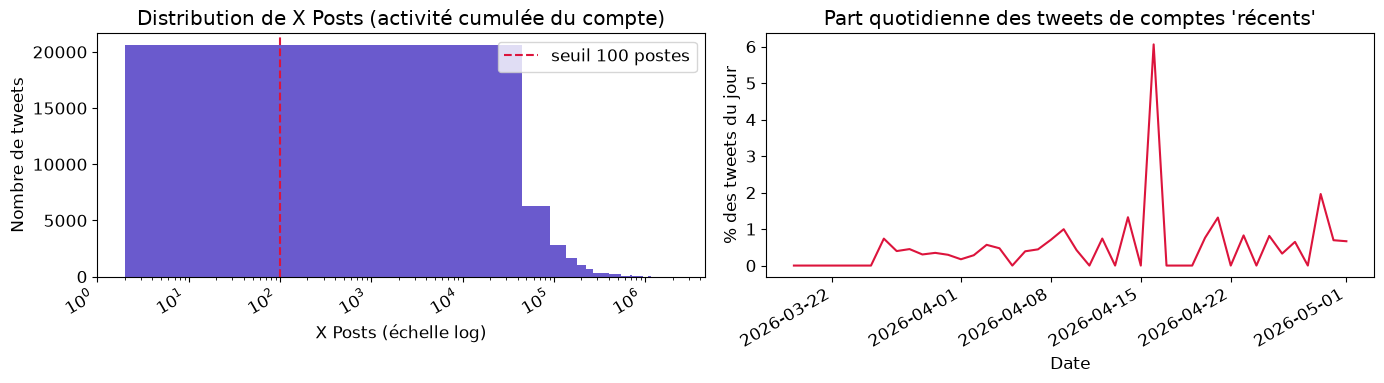

In [6]:
share_recent = _recent_accounts(df, plot=True)

## Sémantique — sur quel ton ?

### 5. Vocabulaire dominant

Mots les plus fréquents du corpus, hors stopwords français.

--- Vocabulaire dominant ---
[('cnc', 48168), ('argent', 12817), ('euros', 11396), ('gauche', 9800), ('francais', 9246), ('ultia', 8355), ('talent', 8179), ('public', 7211), ('aux', 7084), ('france', 6901), ('extreme', 6806), ('commission', 6342), ('fonds', 6215), ('millions', 5970), ('droite', 5665)]
[plot] /home/malo/Documents/PycharmProjects/Datathon/outputs/coord_sem/semantic_vocabulaire_dominant.png


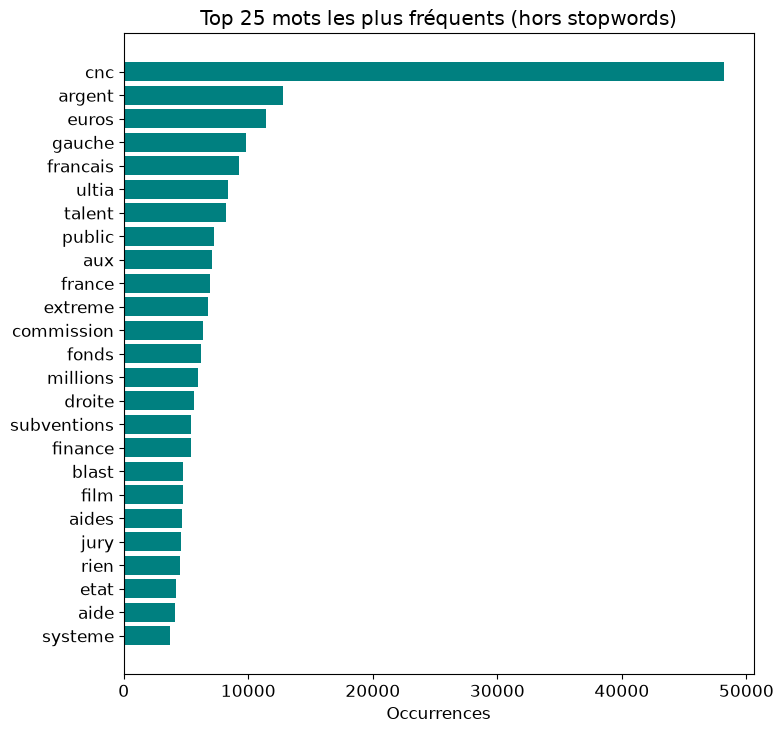

In [7]:
top_words = _dominant_vocabulary(df, plot=True)

### 6. Glissement de vocabulaire

Comparaison de la fréquence relative des mots entre la 1ère et la 2ème moitié
chronologique de la période — quels mots montent, lesquels s'essoufflent.

--- Glissement de vocabulaire (1ère vs 2ème moitié de la période) ---
Mots en hausse (2ème moitié) : [('film', 0.0054151604954568965), ('rien', 0.0027157400681591132), ('monde', 0.0022455754153085285), ('famille', 0.0020774445869254925), ('fausse', 0.0019410312875550407), ('moindre', 0.0019160350348044809), ('finance', 0.0018839872155006977), ('information', 0.0018792855625006705), ('voir', 0.0017868828406164123), ('culture', 0.001777794062129585)]
Mots en baisse (2ème moitié) : [('cnc', -0.01097472747480805), ('ultia', -0.008720602994370167), ('jury', -0.005144435800754496), ('commission', -0.004481224810560408), ('gauche', -0.003960209528424957), ('argent', -0.0036691221789870738), ('politique', -0.003383080155022888), ('projet', -0.0032139045919039938), ('streameuse', -0.003211275293511918), ('obligation', -0.002862396076125454)]
[plot] /home/malo/Documents/PycharmProjects/Datathon/outputs/coord_sem/semantic_glissement_vocabulaire.png


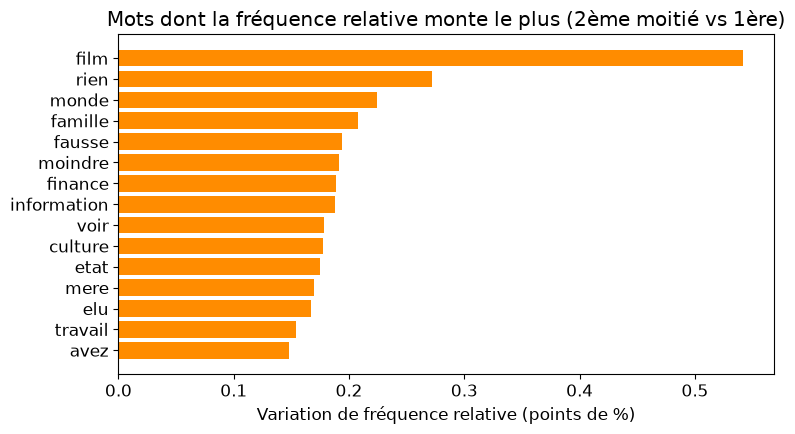

In [8]:
vocab_shift = _vocabulary_shift(df, plot=True)

### 7. Agressivité lexicale

Score par tweet = part de mots appartenant à un petit lexique d'agressivité
(insultes, menaces, accusations graves, appels à l'action), réparti par catégorie.

--- Agressivité ---
20.5% des tweets contiennent au moins un mot du lexique d'agressivité
Score moyen : 0.0040
Répartition par catégorie (occurrences de mots) : {'insulte': 360, 'violence_menace': 1066, 'accusation_grave': 6457, 'appel_action': 673}
[plot] /home/malo/Documents/PycharmProjects/Datathon/outputs/coord_sem/semantic_agressivite.png


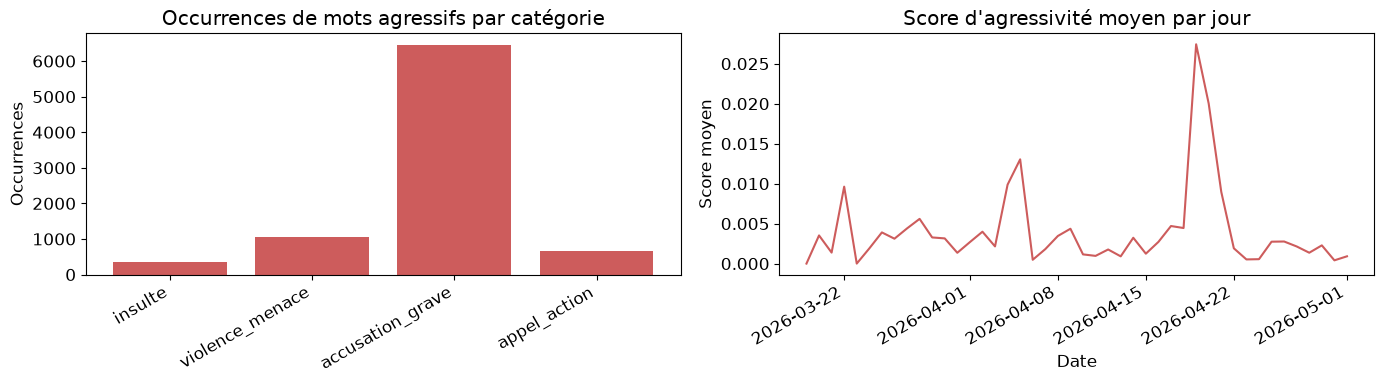

In [9]:
category_hits = _aggressiveness(df, plot=True)

### 8. Escalade du ton

Évolution conjointe du sentiment négatif et du score d'agressivité moyen, jour par jour,
entre la 1ère et la 2ème moitié de la période.

--- Escalade du ton ---
Part de sentiment négatif : 23.9% (1ère moitié de la période) -> 25.4% (2ème moitié)
Evolution de la part de sentiment négatif : +6.43 %
[plot] /home/malo/Documents/PycharmProjects/Datathon/outputs/coord_sem/semantic_escalade.png


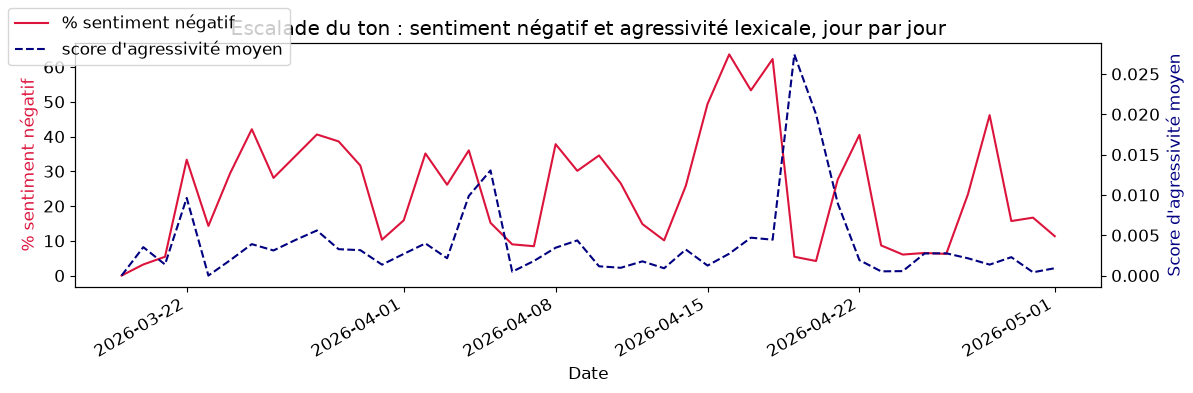

In [10]:
neg_evolution = _escalation(df, plot=True)